# EDA

In [ ]:
import kagglehub
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords

from collections import Counter
from wordcloud import WordCloud

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to dataset files: /kaggle/input/resume-dataset


In [ ]:
import pandas as pd
import os

# Use the 'path' variable which contains the directory of the downloaded dataset
# Assuming the structure is path/Resume/Resume.csv based on the original incorrect path
file_path = os.path.join(path, "Resume", "Resume.csv")
df = pd.read_csv(file_path)

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
print("Dataset shape:", df.shape)

df.info()

df.columns

Dataset shape: (2484, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [ ]:
df.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


In [ ]:
print("Total categories:", df['Category'].nunique())

print(df['Category'].unique())

Total categories: 24
['HR' 'DESIGNER' 'INFORMATION-TECHNOLOGY' 'TEACHER' 'ADVOCATE'
 'BUSINESS-DEVELOPMENT' 'HEALTHCARE' 'FITNESS' 'AGRICULTURE' 'BPO' 'SALES'
 'CONSULTANT' 'DIGITAL-MEDIA' 'AUTOMOBILE' 'CHEF' 'FINANCE' 'APPAREL'
 'ENGINEERING' 'ACCOUNTANT' 'CONSTRUCTION' 'PUBLIC-RELATIONS' 'BANKING'
 'ARTS' 'AVIATION']


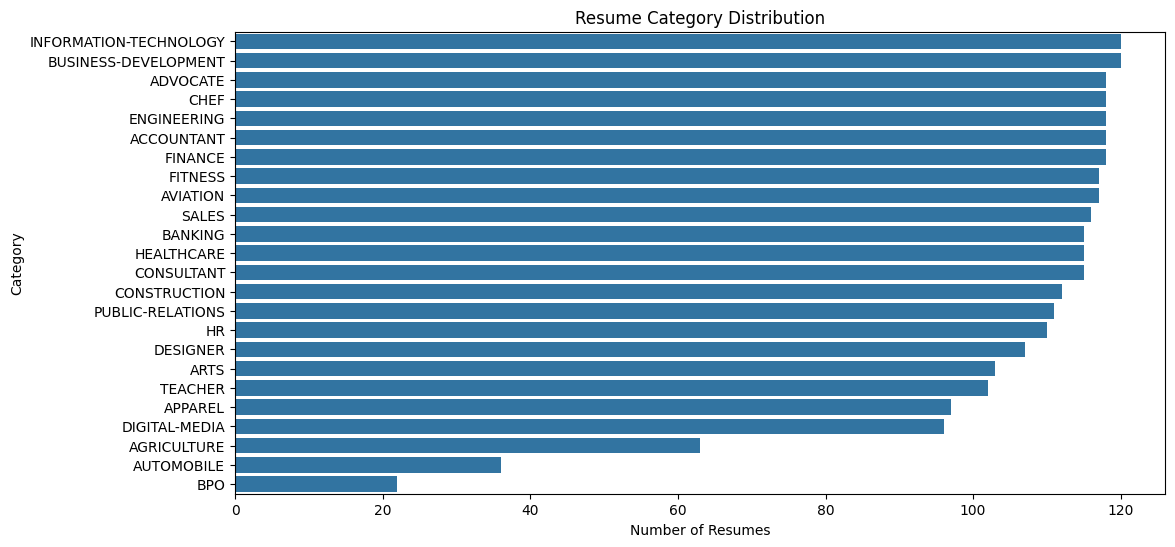

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.countplot(
    y=df['Category'],
    order=df['Category'].value_counts().index
)

plt.title("Resume Category Distribution")

plt.xlabel("Number of Resumes")

plt.show()

In [ ]:
df["char_length"] = df["Resume_str"].apply(len)

df["char_length"].describe()

,char_length
count,2484.000000
mean,6295.308776
std,2769.251458
min,21.000000
25%,5160.000000
50%,5886.500000
75%,7227.250000
max,38842.000000


In [ ]:
df["word_count"] = df["Resume_str"].apply(lambda x: len(x.split()))

df["word_count"].describe()

,word_count
count,2484.000000
mean,811.325684
std,371.006906
min,0.000000
25%,651.000000
50%,757.000000
75%,933.000000
max,5190.000000


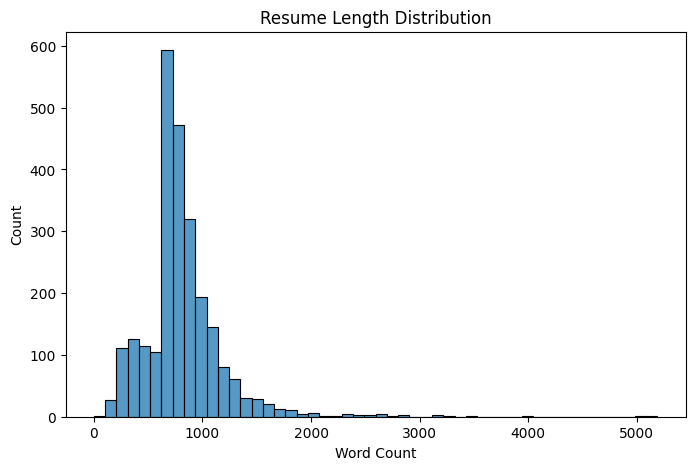

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["word_count"], bins=50)

plt.title("Resume Length Distribution")

plt.xlabel("Word Count")

plt.show()

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df["clean_resume"] = df["Resume_str"].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from collections import Counter

all_words = " ".join(df["clean_resume"]).split()

common_words = Counter(all_words).most_common(20)

common_words

[('state', 16051),
 ('city', 15042),
 ('company', 14630),
 ('management', 11823),
 ('name', 11723),
 ('sales', 8079),
 ('business', 7611),
 ('skills', 7610),
 ('customer', 7531),
 ('new', 6281),
 ('service', 5922),
 ('team', 5807),
 ('development', 5589),
 ('experience', 5562),
 ('training', 5497),
 ('project', 5188),
 ('work', 4679),
 ('information', 4425),
 ('marketing', 4328),
 ('manager', 4278)]

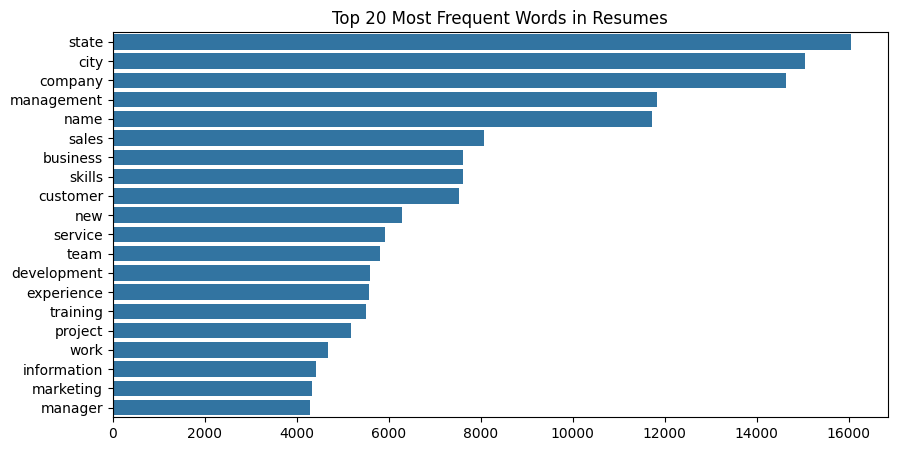

In [ ]:
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,5))

sns.barplot(x=counts, y=words)

plt.title("Top 20 Most Frequent Words in Resumes")

plt.show()

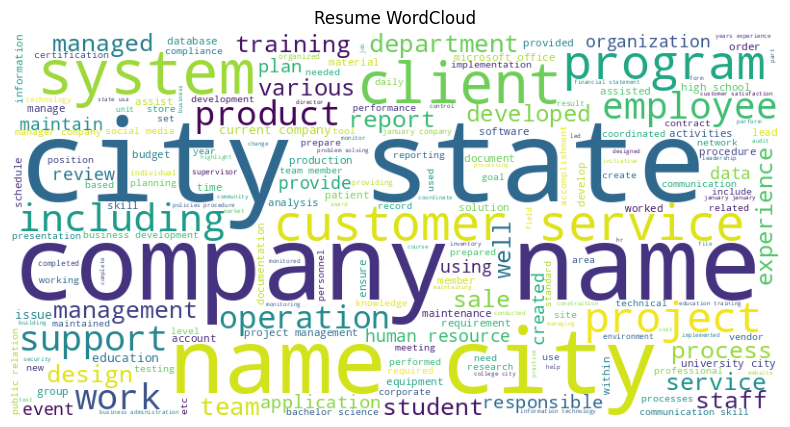

In [ ]:
from wordcloud import WordCloud

text = " ".join(df["clean_resume"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Resume WordCloud")

plt.show()

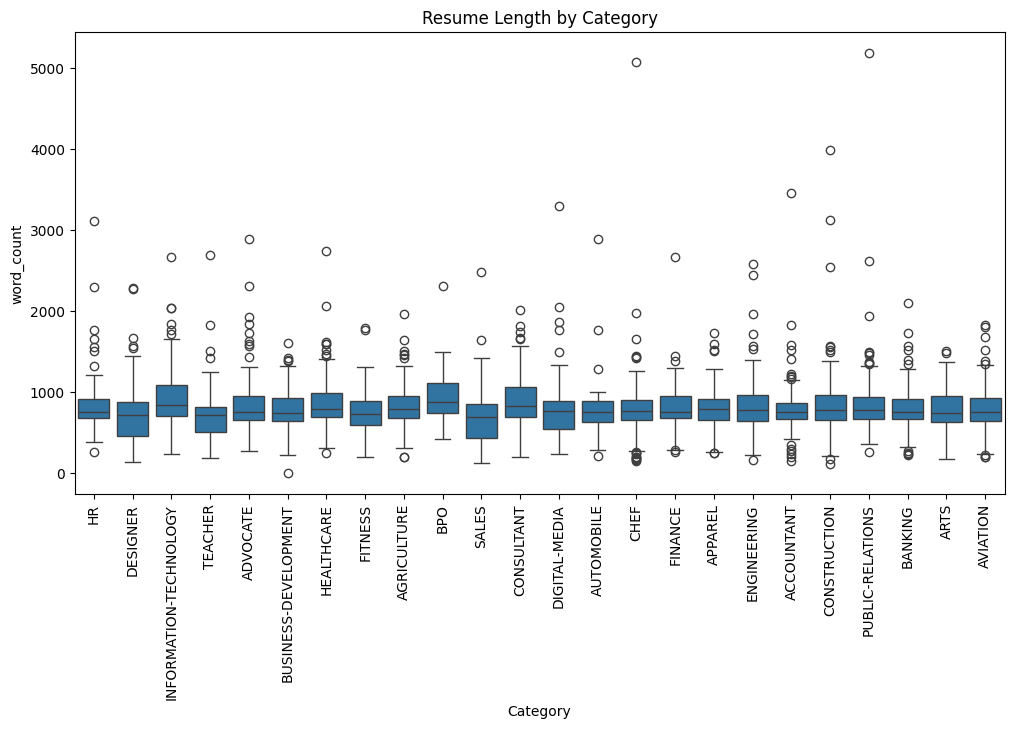

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(x="Category", y="word_count", data=df)

plt.xticks(rotation=90)

plt.title("Resume Length by Category")

plt.show()

# Preprocessing

In [ ]:
import re
import nltk
import pandas as pd

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng') # Added to ensure this specific resource is available

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
import nltk
from nltk.corpus import stopwords

# Initialize stop_words to ensure it's defined
stop_words = set(stopwords.words("english"))

custom_stopwords = {
    "state","city","name","company","resume",
    "curriculum","vitae","email","address",
    "phone","mobile","objective",
    "responsible","work","working","worked",
    "ability","knowledge",
    "year"
}

stop_words = stop_words.union(custom_stopwords)

Text cleaning

In [ ]:
def clean_text(text):

    text = text.lower()

    # Keep +, #, . for skills like C++, C#, Node.js
    text = re.sub(r'[^a-zA-Z0-9+#. ]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

Tokenization + Stop word removal

In [ ]:
def remove_stopwords(text):

    words = text.split() #tokenization

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

Lemmatization

In [ ]:
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

nltk.download('averaged_perceptron_tagger')

lemmatizer = WordNetLemmatizer() # Instantiate the lemmatizer

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize(text):

    words = text.split()

    pos_tags = pos_tag(words)

    words = [lemmatizer.lemmatize(w, get_wordnet_pos(tag)) for w, tag in pos_tags]

    return " ".join(words)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [ ]:
def preprocess_pipeline(text):

    text = clean_text(text)

    text = remove_stopwords(text)

    text = lemmatize(text)

    return text

In [ ]:
df["clean_resume"] = df["Resume_str"].apply(preprocess_pipeline)

Remove empty resume

In [ ]:
df = df[df["clean_resume"].str.strip() != ""]

Remove short resumes

In [ ]:
df = df[df["clean_resume"].str.split().str.len() > 20]

Remove very long resumes

In [ ]:
df = df[df["word_count"] < 3000]

Remove duplicates

In [ ]:
df = df.drop_duplicates(subset="clean_resume")

NER

In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm

import spacy
nlp = spacy.load("en_core_web_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 33.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
def extract_entities(text):

    doc = nlp(text)

    entities = [(ent.text, ent.label_) for ent in doc.ents]

    return entities

df["entities"] = df["clean_resume"].apply(extract_entities)

In [ ]:
skills_list = [

# Programming
"python","java","c","c++","javascript","typescript",

# Data Science
"machine learning","deep learning","nlp","data science",
"pandas","numpy","tensorflow","pytorch","scikit learn",

# Web
"react","angular","node","express","html","css",

# Database
"sql","mysql","mongodb","postgresql",

# Tools
"excel","tableau","power bi","git","docker",

# Domain
"marketing","sales","recruitment","accounting",
"finance","management","autocad","sap"
]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,2),   # capture phrases
    stop_words='english'
)

X = tfidf.fit_transform(df["clean_resume"])

feature_names = tfidf.get_feature_names_out()

In [ ]:
import numpy as np

def extract_top_keywords(row, top_n=10):

    row_array = row.toarray().flatten()

    top_indices = np.argsort(row_array)[-top_n:]

    return [feature_names[i] for i in top_indices]

df["tfidf_skills"] = [extract_top_keywords(X[i]) for i in range(X.shape[0])]

In [ ]:
def extract_known_skills(text, skill_list):
    found_skills = []
    for skill in skill_list:
        # Use word boundaries to match whole words and handle variations like C++
        if re.search(r'\b' + re.escape(skill) + r'\b', text, re.IGNORECASE):
            found_skills.append(skill)
    return found_skills

df["skills"] = df["clean_resume"].apply(lambda x: extract_known_skills(x, skills_list))

def combine_skills(row):
    return list(set(row["skills"] + row["tfidf_skills"]))

df["final_skills"] = df.apply(combine_skills, axis=1)

In [ ]:
from spacy.matcher import PhraseMatcher

matcher = PhraseMatcher(nlp.vocab)

patterns = [nlp(skill) for skill in skills_list]

matcher.add("SKILLS", patterns)

def extract_skills_spacy(text):

    doc = nlp(text)

    matches = matcher(doc)

    skills = set()

    for match_id, start, end in matches:
        skills.add(doc[start:end].text)

    return list(skills)

df["skills_spacy"] = df["clean_resume"].apply(extract_skills_spacy)

In [ ]:
for i in range(3):
    print("ORIGINAL:\n", df["Resume_str"].iloc[i][:300])
    print("\nCLEANED:\n", df["clean_resume"].iloc[i][:300])
    print("\n" + "="*80)

ORIGINAL:
          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

CLEANED:
 hr administrator marketing associate hr administrator summary dedicate customer service manager 15+ year experience hospitality customer service management. respect builder leader customer focus team strives instill share enthusiastic commitment customer service. highlight focus customer satisfactio

ORIGINAL:
          HR SPECIALIST, US HR OPERATIONS       Summary     Versatile  media professional with background in Communications, Marketing, Human Resources and Technology.         Experience     09/2015   to   Current     HR Specialist, US HR Operations    Company Name   －   City  ,   State       Managed

CLEANED:
 hr specialist u hr operation summary versatile mediu

In [ ]:
df[["Resume_str", "clean_resume"]].head(5)

,Resume_str,clean_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist u hr operation summary versatile...
2,HR DIRECTOR Summary Over 2...,hr director summary 20 year experience recruit...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicate driven dynamic ...
4,HR MANAGER Skill Highlights ...,hr manager skill highlight hr skill hr departm...


In [ ]:
df["clean_word_count"] = df["clean_resume"].apply(lambda x: len(x.split()))

df[["word_count", "clean_word_count"]].head()

,word_count,clean_word_count
0,674,479
1,708,521
2,1017,704
3,379,256
4,1206,876


In [ ]:
from collections import Counter

all_words = " ".join(df["clean_resume"]).split()

common_words = Counter(all_words).most_common(20)

common_words

[('management', 11298),
 ('customer', 10521),
 ('sale', 8170),
 ('service', 8144),
 ('business', 7721),
 ('project', 7059),
 ('skill', 6894),
 ('team', 6497),
 ('manage', 6393),
 ('new', 6354),
 ('system', 6062),
 ('include', 6019),
 ('client', 5924),
 ('experience', 5835),
 ('develop', 5596),
 ('process', 5566),
 ('maintain', 5503),
 ('provide', 5454),
 ('development', 5424),
 ('manager', 5169)]

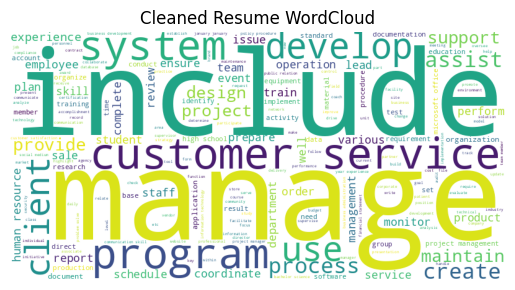

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["clean_resume"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Cleaned Resume WordCloud")
plt.show()

In [ ]:
print("Final dataset shape:", df.shape)

Final dataset shape: (2474, 13)


In [ ]:
df[["clean_resume", "skills"]].head(5)

,clean_resume,skills
0,hr administrator marketing associate hr admini...,"[marketing, accounting, management]"
1,hr specialist u hr operation summary versatile...,"[marketing, recruitment, management]"
2,hr director summary 20 year experience recruit...,"[express, excel, marketing, recruitment, manag..."
3,hr specialist summary dedicate driven dynamic ...,"[excel, management]"
4,hr manager skill highlight hr skill hr departm...,"[excel, recruitment, management]"


# LOGISTIC REGRESSION

In [ ]:
# =========================================
# LOGISTIC REGRESSION
# =========================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack

# =========================================
# 1. LIGHT CLASS FILTER
# =========================================
df = df[df['Category'].map(df['Category'].value_counts()) > 20]

# =========================================
# 2. TF-IDF FEATURES
# =========================================
tfidf_word = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    max_df=0.95,
    min_df=2,
    sublinear_tf=True
)

X_word = tfidf_word.fit_transform(df["clean_resume"])

tfidf_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=8000
)

X_char = tfidf_char.fit_transform(df["clean_resume"])

# =========================================
# 3. SBERT
# =========================================
from sentence_transformers import SentenceTransformer
from scipy.sparse import csr_matrix

bert_model = SentenceTransformer('all-mpnet-base-v2')

X_bert = bert_model.encode(
    df["clean_resume"].tolist(),
    show_progress_bar=True,
    batch_size=32
)

X_bert_sparse = csr_matrix(X_bert)

# =========================================
# 4. FEATURE FUSION
# =========================================
X = hstack([X_word, X_char, X_bert_sparse])
y = df["Category"]

# =========================================
# 5. TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================================
# 6. SCALING
# =========================================
scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================
# 7. MODEL
# =========================================
model = LogisticRegression(
    max_iter=5000,
    solver='saga',
    C=2,
    class_weight='balanced',
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================================
# 8. EVALUATION
# =========================================
y_pred = model.predict(X_test)

print("ACCURACY:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

ACCURACY: 0.7717171717171717

                         precision    recall  f1-score   support

            ACCOUNTANT       0.75      1.00      0.86        24
              ADVOCATE       0.70      0.79      0.75        24
           AGRICULTURE       0.83      0.38      0.53        13
               APPAREL       0.60      0.47      0.53        19
                  ARTS       0.85      0.52      0.65        21
            AUTOMOBILE       0.80      0.57      0.67         7
              AVIATION       0.77      0.87      0.82        23
               BANKING       0.89      0.70      0.78        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.89      1.00      0.94        24
                  CHEF       0.95      0.78      0.86        23
          CONSTRUCTION       0.82      0.64      0.72        22
            CONSULTANT       0.67      0.70      0.68        23
              DESIGNER       0.86      0.90      0.88        21
        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# HYBRID (TF-IDF + SBERT + XGBOOST )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:59:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBOOST (HYBRID) PERFORMANCE =====
Accuracy: 0.8202

Classification Report:

                        precision    recall  f1-score   support

            ACCOUNTANT       0.83      1.00      0.91        24
              ADVOCATE       0.86      0.79      0.83        24
           AGRICULTURE       0.67      0.46      0.55        13
               APPAREL       0.87      0.68      0.76        19
                  ARTS       0.56      0.48      0.51        21
            AUTOMOBILE       0.80      0.57      0.67         7
              AVIATION       0.83      0.83      0.83        23
               BANKING       0.90      0.78      0.84        23
                   BPO       0.67      0.50      0.57         4
  BUSINESS-DEVELOPMENT       0.96      1.00      0.98        24
                  CHEF       1.00      0.83      0.90        23
          CONSTRUCTION       0.95      0.86      0.90        22
            CONSULTANT       0.80      0.70      0.74        23
              DESIG

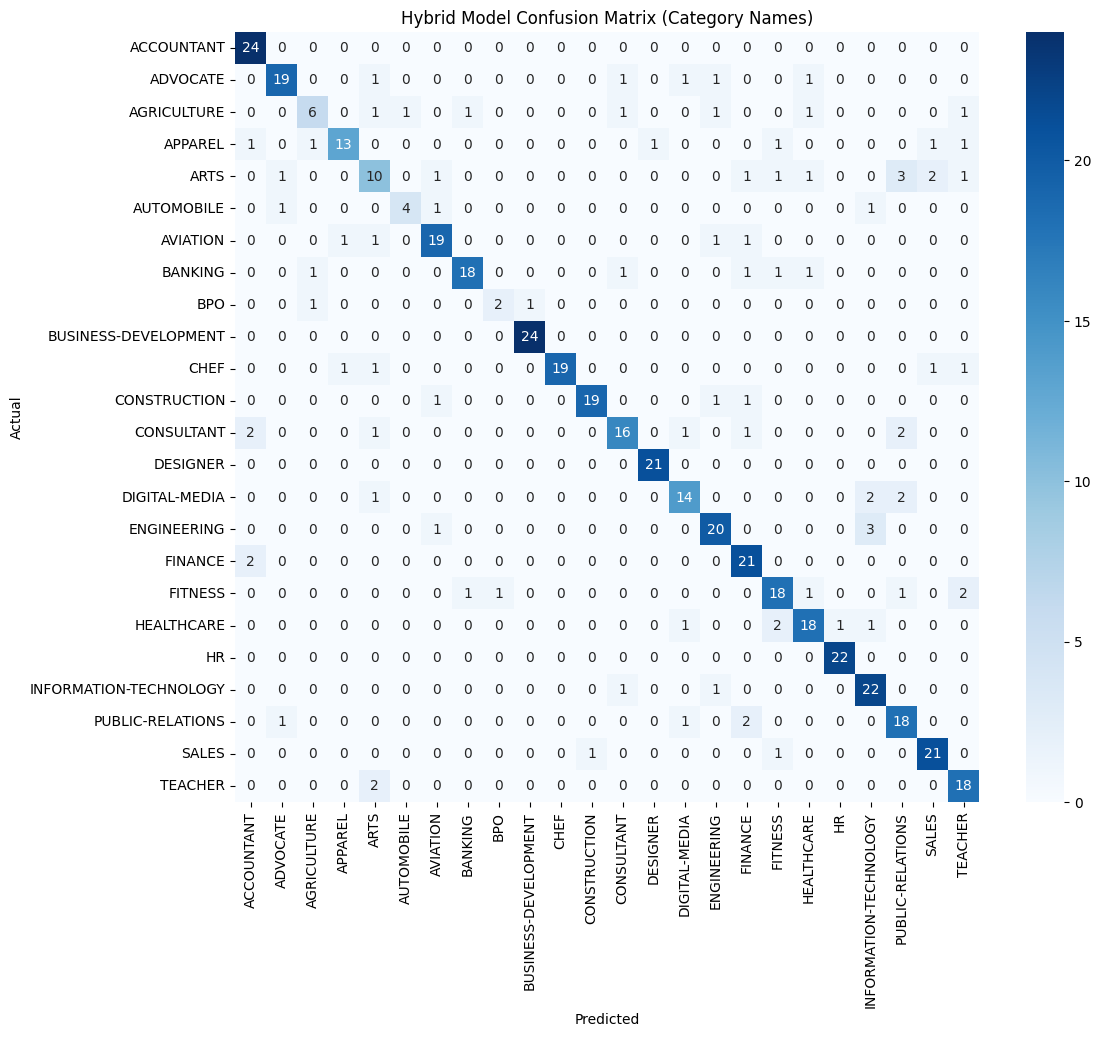


===== SELECTION RATE =====
Predicted
INFORMATION-TECHNOLOGY    0.058586
ACCOUNTANT                0.058586
FINANCE                   0.056566
PUBLIC-RELATIONS          0.052525
BUSINESS-DEVELOPMENT      0.050505
ENGINEERING               0.050505
SALES                     0.050505
FITNESS                   0.048485
TEACHER                   0.048485
HEALTHCARE                0.046465
AVIATION                  0.046465
HR                        0.046465
ADVOCATE                  0.044444
DESIGNER                  0.044444
CONSTRUCTION              0.040404
CONSULTANT                0.040404
BANKING                   0.040404
CHEF                      0.038384
ARTS                      0.036364
DIGITAL-MEDIA             0.036364
APPAREL                   0.030303
AGRICULTURE               0.018182
AUTOMOBILE                0.010101
BPO                       0.006061
Name: proportion, dtype: float64

===== FAIRNESS TABLE =====
                        Selection Rate  Statistical Parity
Pr

In [ ]:
"""#  HYBRID MODEL (TF-IDF + SBERT + XGBOOST )"""

# =========================================
# 1. IMPORTS
# =========================================
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, normalize

from scipy.sparse import hstack, csr_matrix

from sentence_transformers import SentenceTransformer
from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt

# =========================================
# 2. DATA SAFETY CHECK
# =========================================
df = df[df["clean_resume"].notnull()]
df = df[df["clean_resume"].str.strip() != ""]

# =========================================
# 3. LABEL ENCODING
# =========================================
le = LabelEncoder()
y = le.fit_transform(df["Category"])

# =========================================
# 4. TF-IDF
# =========================================
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    max_df=0.85,
    min_df=3,
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(df["clean_resume"])

# =========================================
# 5. SBERT EMBEDDINGS
# =========================================
bert_model = SentenceTransformer('all-mpnet-base-v2')

X_bert = bert_model.encode(
    df["clean_resume"].tolist(),
    show_progress_bar=True,
    batch_size=32
)

X_bert_sparse = csr_matrix(X_bert)

# =========================================
# 6. NORMALIZATION + FUSION
# =========================================
X_tfidf = normalize(X_tfidf)
X_bert_sparse = normalize(X_bert_sparse)

X = hstack([X_tfidf, X_bert_sparse * 3])

# =========================================
# 7. TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================================
# 8. XGBOOST MODEL
# =========================================
model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_lambda=1,
    tree_method='hist',
    eval_metric='mlogloss',
    use_label_encoder=False
)

model.fit(X_train, y_train)

# =========================================
# 9. PREDICTION
# =========================================
y_pred = model.predict(X_test)

# =========================================
# 10. EVALUATION (XGBOOST ACCURACY)
# =========================================
xgb_accuracy = accuracy_score(y_test, y_pred)

print("\n===== XGBOOST (HYBRID) PERFORMANCE =====")
print(f"Accuracy: {xgb_accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# =========================================
# 11. DECODE LABELS
# =========================================
pred_labels = le.inverse_transform(y_pred)
true_labels = le.inverse_transform(y_test)

# =========================================
# 12.CONFUSION MATRIX
# =========================================
cm = confusion_matrix(y_test, y_pred)

labels = le.inverse_transform(np.unique(y_test))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap="Blues")

plt.title("Hybrid Model Confusion Matrix (Category Names)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# =========================================
# 13.FAIRNESS ANALYSIS
# =========================================
category_df = pd.DataFrame({
    "Actual": true_labels,
    "Predicted": pred_labels
})

category_df["correct"] = category_df["Actual"] == category_df["Predicted"]

# Selection Rate
selection_rate = category_df["Predicted"].value_counts(normalize=True)

print("\n===== SELECTION RATE =====")
print(selection_rate)

# Statistical Parity per class
stat_parity = selection_rate - selection_rate.mean()

fairness_df = pd.DataFrame({
    "Selection Rate": selection_rate,
    "Statistical Parity": stat_parity
})

print("\n===== FAIRNESS TABLE =====")
print(fairness_df)

# Overall SPD
spd = selection_rate.max() - selection_rate.min()

print("\n===== STATISTICAL PARITY DIFFERENCE =====")
print("SPD:", round(spd, 4))

# BERT

In [ ]:
# =========================================
# SECTION 1: DATA ACQUISITION
# =========================================
import kagglehub
import glob
import os

path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")
print("Dataset path:", path)

csv_files = glob.glob(path + "/**/*.csv", recursive=True)

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV found!")

file_path = csv_files[0]
print("Using file:", file_path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Dataset path: /kaggle/input/resume-dataset
Using file: /kaggle/input/resume-dataset/Resume/Resume.csv


In [ ]:
# =========================================
# SECTION 2: IMPORTS & SETUP
# =========================================
import pandas as pd
import numpy as np
import torch
import random
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

from torch.nn import CrossEntropyLoss

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# =========================================
# SECTION 3: DATA PREPROCESSING
# =========================================
df = pd.read_csv(file_path)
df = df[df["Resume_str"].notnull()]

def clean_text_bert(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9., ]', '', text)
    return text.strip()

df["bert_text"] = df["Resume_str"].apply(clean_text_bert)

# Remove small classes
df = df[df['Category'].map(df['Category'].value_counts()) > 30]

# Label encoding
le = LabelEncoder()
df["label"] = le.fit_transform(df["Category"])

In [ ]:
# =========================================
# SECTION 4: TRAIN-TEST SPLIT
# =========================================
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["bert_text"],
    df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [ ]:
# =========================================
# SECTION 5: TOKENIZATION
# =========================================
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

def tokenize(texts):
    return tokenizer(list(texts), truncation=True, max_length=384)

train_encodings = tokenize(train_texts)
test_encodings = tokenize(test_texts)

In [ ]:
# =========================================
# SECTION 6: DATASET CLASS
# =========================================
class ResumeDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ResumeDataset(train_encodings, train_labels)
test_dataset = ResumeDataset(test_encodings, test_labels)

In [ ]:
# =========================================
# SECTION 7: MODEL + CLASS WEIGHTS
# =========================================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(le.classes_)
)

model.to(device)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# =========================================
# SECTION 8: CUSTOM TRAINER
# =========================================
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
# =========================================
# SECTION 9: TRAINING CONFIGURATION
# =========================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    save_total_limit=2
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
# =========================================
# SECTION 10: MODEL TRAINING
# =========================================
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.850927,1.944446,0.685598,0.635705
2,1.491994,0.971447,0.829615,0.819004
3,0.789539,0.832781,0.839757,0.833017
4,0.681822,0.760044,0.862069,0.858338


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=496, training_loss=1.4716690048094718, metrics={'train_runtime': 692.7823, 'train_samples_per_second': 11.369, 'train_steps_per_second': 0.716, 'total_flos': 1554413978795064.0, 'train_loss': 1.4716690048094718, 'epoch': 4.0})

In [ ]:
# =========================================
# SAVE TRAINED MODEL
# =========================================
model_path = "./bert_resume1_model"

# Save model + tokenizer
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

# =========================================
# SAVE LABEL ENCODER
# =========================================
import joblib
joblib.dump(le, os.path.join(model_path, "label_encoder.pkl"))

print("Model, tokenizer, and label encoder saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model, tokenizer, and label encoder saved successfully!


In [ ]:
# =========================================
# SECTION 11: FULL EVALUATION
# =========================================
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

accuracy = accuracy_score(test_labels, y_pred)
precision = precision_score(test_labels, y_pred, average="weighted")
recall = recall_score(test_labels, y_pred, average="weighted")
f1 = f1_score(test_labels, y_pred, average="weighted")

print("\n===== PERFORMANCE =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(test_labels, y_pred, target_names=le.classes_))


===== PERFORMANCE =====
Accuracy : 0.8621
Precision: 0.8616
Recall   : 0.8621
F1 Score : 0.8583

===== CLASSIFICATION REPORT =====
                        precision    recall  f1-score   support

            ACCOUNTANT       0.92      1.00      0.96        24
              ADVOCATE       0.77      0.83      0.80        24
           AGRICULTURE       0.83      0.77      0.80        13
               APPAREL       0.56      0.53      0.54        19
                  ARTS       0.72      0.62      0.67        21
            AUTOMOBILE       0.75      0.43      0.55         7
              AVIATION       0.90      0.79      0.84        24
               BANKING       0.84      0.70      0.76        23
  BUSINESS-DEVELOPMENT       0.96      1.00      0.98        24
                  CHEF       0.95      0.88      0.91        24
          CONSTRUCTION       0.95      0.91      0.93        22
            CONSULTANT       0.96      0.96      0.96        23
              DESIGNER       0.95  

In [ ]:
try:
    probs = torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy()
    auc = roc_auc_score(test_labels, probs, multi_class="ovr")
    print("\nROC-AUC:", round(auc, 4))
except:
    print("ROC-AUC could not be computed.")


ROC-AUC: 0.9808


In [ ]:
test_df = pd.DataFrame({
    "text": test_texts,
    "true": test_labels,
    "pred": y_pred
})

test_df["correct"] = test_df["true"] == test_df["pred"]

test_df["length"] = test_df["text"].apply(lambda x: len(x.split()))
median_len = test_df["length"].median()

test_df["group"] = np.where(test_df["length"] > median_len,
                            "Long Resume", "Short Resume")

print("\n===== FAIRNESS: LENGTH =====")
print(test_df.groupby("group")["correct"].mean())


===== FAIRNESS: LENGTH =====
group
Long Resume     0.865854
Short Resume    0.858300
Name: correct, dtype: float64


In [ ]:
category_df = pd.DataFrame({
    "Actual": le.inverse_transform(test_labels),
    "Predicted": le.inverse_transform(y_pred)
})

category_df["correct"] = category_df["Actual"] == category_df["Predicted"]

print("\n===== PER-CATEGORY ACCURACY =====")
print(category_df.groupby("Actual")["correct"].mean().sort_values())


===== PER-CATEGORY ACCURACY =====
Actual
AUTOMOBILE                0.428571
APPAREL                   0.526316
ARTS                      0.619048
FITNESS                   0.652174
BANKING                   0.695652
HEALTHCARE                0.739130
AGRICULTURE               0.769231
AVIATION                  0.791667
ADVOCATE                  0.833333
DIGITAL-MEDIA             0.842105
CHEF                      0.875000
CONSTRUCTION              0.909091
PUBLIC-RELATIONS          0.909091
SALES                     0.956522
CONSULTANT                0.956522
ENGINEERING               0.958333
INFORMATION-TECHNOLOGY    0.958333
DESIGNER                  1.000000
BUSINESS-DEVELOPMENT      1.000000
ACCOUNTANT                1.000000
FINANCE                   1.000000
HR                        1.000000
TEACHER                   1.000000
Name: correct, dtype: float64


In [ ]:
selection_rate = category_df["Predicted"].value_counts(normalize=True)
spd = selection_rate.max() - selection_rate.min()

print("\n===== STATISTICAL PARITY DIFFERENCE =====")
print("SPD:", round(spd, 4))


===== STATISTICAL PARITY DIFFERENCE =====
SPD: 0.0446


In [ ]:
# =========================================
# FALSE POSITIVE / NEGATIVE ANALYSIS
# =========================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, y_pred)

fp = cm.sum(axis=0) - np.diag(cm)
fn = cm.sum(axis=1) - np.diag(cm)

fp_df = pd.DataFrame({
    "Category": le.classes_,
    "False_Positive": fp,
    "False_Negative": fn
})

print("\n===== ERROR DISTRIBUTION =====")
print(fp_df.sort_values(by="False_Negative", ascending=False))


===== ERROR DISTRIBUTION =====
                  Category  False_Positive  False_Negative
3                  APPAREL               8               9
4                     ARTS               5               8
16                 FITNESS               2               8
7                  BANKING               3               7
17              HEALTHCARE               5               6
6                 AVIATION               2               5
1                 ADVOCATE               6               4
5               AUTOMOBILE               1               4
2              AGRICULTURE               2               3
13           DIGITAL-MEDIA               6               3
9                     CHEF               1               3
10            CONSTRUCTION               1               2
20        PUBLIC-RELATIONS               5               2
21                   SALES               3               1
14             ENGINEERING               3               1
11              CONSULTA

In [ ]:
# =========================================
# CONFIDENCE ANALYSIS
# =========================================
confidence = np.max(probs, axis=1)

conf_df = pd.DataFrame({
    "confidence": confidence,
    "correct": (y_pred == test_labels)
})

print("\n===== CONFIDENCE ANALYSIS =====")
print(conf_df.groupby("correct")["confidence"].mean())


===== CONFIDENCE ANALYSIS =====
correct
False    0.465056
True     0.789385
Name: confidence, dtype: float32
